# Fase 4 - ¿Predice el audio la popularidad?

El EDA mostró correlaciones casi nulas entre features de audio y `popularity`. Aquí lo
demostramos de verdad: entrenamos modelos a predecir la popularidad solo con el audio y medimos
el R². Si ni un Random Forest lo consigue, queda probado que la popularidad depende de factores
que el audio no captura (marketing, artista, momento). El resultado negativo es el hallazgo.

In [1]:
# Bootstrap: ejecutable desde cualquier carpeta (jupyter nbconvert).
import sys
from pathlib import Path
_root = Path.cwd()
while not (_root / "config.yaml").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from src.config import load_config, path
from src import popularity

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "axes.titleweight": "bold"})
cfg = load_config(); REPORTS = path(cfg["paths"]["reports"])

out = popularity.train_models(cfg)
for nombre, m in out["results"].items():
    print(f"{nombre:<20} R2={m['r2']:.3f}  MAE={m['mae']:.1f}")

Linear Regression    R2=0.028  MAE=16.6
Random Forest        R2=0.161  MAE=15.0


## Predicho vs. real (mejor modelo)

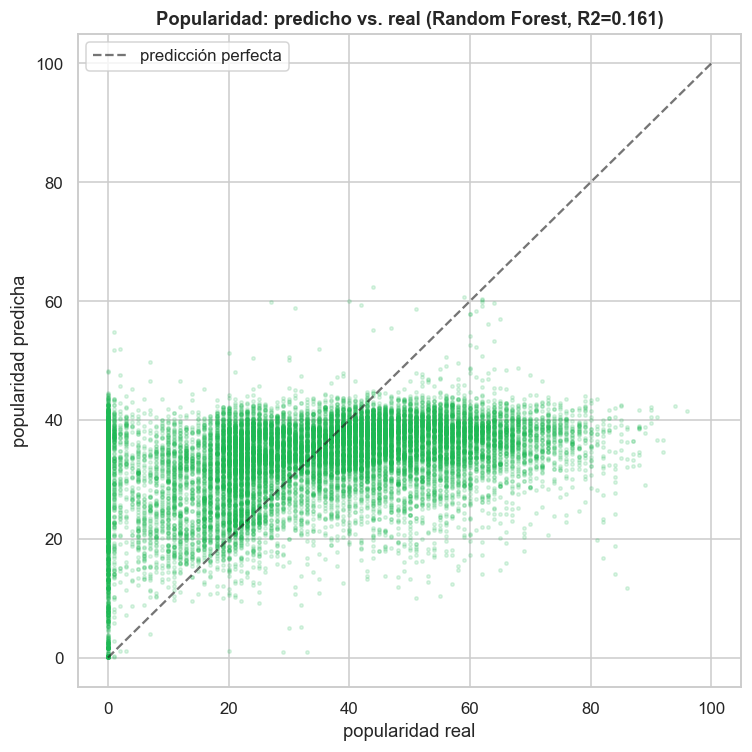

Guardado reports/popularity_metrics.json


In [2]:
best = max(out["results"], key=lambda k: out["results"][k]["r2"])
y, p = out["y_test"], out["preds"][best]
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y, p, s=5, alpha=.15, color="#1DB954")
ax.plot([0, 100], [0, 100], "k--", alpha=.6, label="predicción perfecta")
ax.set_title(f"Popularidad: predicho vs. real ({best}, R2={out['results'][best]['r2']:.3f})")
ax.set_xlabel("popularidad real"); ax.set_ylabel("popularidad predicha"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS / "12_popularity_pred.png", bbox_inches="tight"); plt.show()

# Guardamos el resultado para la documentación
res = {"target": "popularity", "models": {k: {kk: round(vv, 3) for kk, vv in v.items()}
                                          for k, v in out["results"].items()},
       "best_model": best, "best_r2": round(out["results"][best]["r2"], 3)}
json.dump(res, open(REPORTS / "popularity_metrics.json", "w", encoding="utf-8"),
          indent=2, ensure_ascii=False)
print("Guardado reports/popularity_metrics.json")

## Conclusión

El R² es bajísimo incluso con Random Forest: la nube de puntos no se acerca a la diagonal. Las
features de audio **no explican** la popularidad. No es un fallo del modelo — es que la señal no
está en el audio. Por eso este proyecto se centra en describir y agrupar (clustering), no en
predecir popularidad: forzar un modelo aquí sería vender humo.